# LSTM vs GRU 성능 & 속도 비교

**IMDB 영화 리뷰 감성 분류** 문제를 통해 LSTM과 GRU 두 모델을 직접 비교해보겠습니다 !

> **실행 방법: Colab 상단 메뉴에서 `연결 > 런타임 유형 변경 > T4 GPU`로 설정한 뒤, 각 셀을 위에서부터 순서대로 실행해주세요.**

## 0. 실습 개요

**태스크**: IMDB 영화 리뷰가 긍정(1)인지 부정(0)인지 분류하는 이진 분류 문제

임베딩 층(Embedding) + 순환층(LSTM 또는 GRU) + 출력층(Dense) 구조를 동일하게 맞추고, 순환층만 LSTM ↔ GRU로 바꿔서 공정하게 비교.

## 1단계. 라이브러리 불러오기 및 GPU 확인

먼저 필요한 라이브러리를 불러오고, GPU가 잘 연결되어 있는지 확인합니다.
GPU가 없으면 학습 시간이 훨씬 오래 걸리니 꼭 확인해주세요!

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense

# 재현성을 위한 시드 고정
tf.random.set_seed(42)
np.random.seed(42)

# GPU 사용 가능 여부 확인
print("사용 가능한 장치:")
print(tf.config.list_physical_devices('GPU'))
if len(tf.config.list_physical_devices('GPU')) == 0:
    print("⚠️ GPU가 연결되어 있지 않습니다. 연결 > 런타임 유형 변경 > T4 GPU로 설정해주세요.")
else:
    print("✅ GPU 연결 확인 완료!")


사용 가능한 장치:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU 연결 확인 완료!


## 2단계. 데이터 준비 (IMDB 영화 리뷰)

*Keras에는 IMDB 영화 리뷰 5만 건이 내장되어 있습니다.
단어는 이미 정수 인덱스로 변환되어 있어서 바로 학습에 사용할 수 있습니다.

- `vocab_size`: 등장 빈도 상위 몇 개의 단어만 사용할지 (나머지는 무시)
   
   *keras에 있는 모든 단어를 사용하기에는 시간이 너무 오래걸림
- `max_len`: 리뷰 하나당 최대 단어 길이 (넘으면 자르고, 모자라면 0으로 채움 → padding)
   
   *문장 길이 맞추기

In [3]:
# 하이퍼파라미터 설정
vocab_size = 10000    # 상위 10,000개 단어만 사용
max_len = 200         # 리뷰 하나당 최대 200단어
embedding_dim = 32    # 임베딩 벡터 차원

# 데이터 로드 (처음 실행 시 자동 다운로드됨)
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print(f"학습 데이터 개수: {len(x_train)}")
print(f"테스트 데이터 개수: {len(x_test)}")
print(f"첫 번째 리뷰(정수 인덱스, 앞 20개): {x_train[0][:20]}")
print(f"첫 번째 리뷰의 라벨: {y_train[0]} (1=긍정, 0=부정)")

# 리뷰 길이를 max_len으로 통일 (padding)
x_train = pad_sequences(x_train, maxlen=max_len, padding='post', truncating='post')
x_test = pad_sequences(x_test, maxlen=max_len, padding='post', truncating='post')

print(f"\npadding 후 shape: {x_train.shape}  (샘플 수, 시퀀스 길이)")


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
학습 데이터 개수: 25000
테스트 데이터 개수: 25000
첫 번째 리뷰(정수 인덱스, 앞 20개): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
첫 번째 리뷰의 라벨: 1 (1=긍정, 0=부정)

padding 후 shape: (25000, 200)  (샘플 수, 시퀀스 길이)


## 3단계. 모델 설계

**공정한 비교**를 위해 두 모델은 딱 한 층(LSTM ↔ GRU)만 다르고 나머지 구조는 동일합니다.

```
입력 시퀀스
   ↓
Embedding (단어 → 벡터)
   ↓
LSTM 또는 GRU (시퀀스 정보 요약)
   ↓
Dense (이진 분류, sigmoid)
   ↓
출력 (0~1 사이 확률)
```

### 3-1. GRU 셀 직접 구현해보기

앞서 배운 GRU 수식을 그대로 코드로 옮기면 다음과 같습니다.

$$r_t = \sigma(x_t W_r + h_{t-1} U_r + b_r) \quad \text{(리셋 게이트)}$$
$$z_t = \sigma(x_t W_z + h_{t-1} U_z + b_z) \quad \text{(업데이트 게이트)}$$
$$\tilde h_t = \tanh(x_t W_h + (r_t \odot h_{t-1}) U_h + b_h) \quad \text{(후보 은닉상태)}$$
$$h_t = (1-z_t) \odot h_{t-1} + z_t \odot \tilde h_t \quad \text{(최종 은닉상태)}$$

`tf.keras.layers.RNN`이 시간 축(time step)을 따라 이 셀을 자동으로 반복 호출해줍니다.
우리는 **한 시점(time step)에서 무슨 계산이 일어나는지**만 `call()` 안에 정의하면 됩니다.

In [5]:
class GRUCellCustom(tf.keras.layers.Layer):

    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.state_size = units
        self.output_size = units

    def build(self, input_shape):
        input_dim = input_shape[-1]
        u = self.units

        # --- 리셋 게이트(r_t) 파라미터: W_r, U_r, b_r ---
        self.Wr = self.add_weight(shape=(input_dim, u), initializer='glorot_uniform', name='Wr')
        self.Ur = self.add_weight(shape=(u, u), initializer='orthogonal', name='Ur')
        self.br = self.add_weight(shape=(u,), initializer='zeros', name='br')

        # --- 업데이트 게이트(z_t) 파라미터: W_z, U_z, b_z ---
        self.Wz = self.add_weight(shape=(input_dim, u), initializer='glorot_uniform', name='Wz')
        self.Uz = self.add_weight(shape=(u, u), initializer='orthogonal', name='Uz')
        self.bz = self.add_weight(shape=(u,), initializer='zeros', name='bz')

        # --- 후보 은닉상태(h_tilde) 파라미터: W_h, U_h, b_h ---
        self.Wh = self.add_weight(shape=(input_dim, u), initializer='glorot_uniform', name='Wh')
        self.Uh = self.add_weight(shape=(u, u), initializer='orthogonal', name='Uh')
        self.bh = self.add_weight(shape=(u,), initializer='zeros', name='bh')

        super().build(input_shape)

    def call(self, inputs, states):
        # inputs: 현재 시점의 입력 x_t,  states[0]: 이전 은닉상태 h_{t-1}
        x_t = inputs
        h_prev = states[0]

        # 식을 참고해서 코드 작성해주세요.
        r_t = tf.sigmoid(tf.matmul(x_t, self.Wr) + tf.matmul(h_prev, self.Ur) + self.br)
        z_t = tf.sigmoid(tf.matmul(x_t, self.Wz) + tf.matmul(h_prev, self.Uz) + self.bz)
        h_tilde = tf.tanh(tf.matmul(x_t, self.Wh) + tf.matmul(r_t * h_prev, self.Uh) + self.bh)
        h_t = (1 - z_t) * h_prev + z_t * h_tilde


        return h_t, [h_t]


### 3-2. LSTM 셀 직접 구현해보기


LSTM은 셀 상태 $c_t$와 은닉 상태 $h_t$ 두 개를 함께 관리하고, 게이트가 3개(망각/입력/출력)입니다.

$$f_t = \sigma(x_t W_f + h_{t-1} U_f + b_f) \quad \text{(망각 게이트)}$$
$$i_t = \sigma(x_t W_i + h_{t-1} U_i + b_i) \quad \text{(입력 게이트)}$$
$$o_t = \sigma(x_t W_o + h_{t-1} U_o + b_o) \quad \text{(출력 게이트)}$$
$$\tilde c_t = \tanh(x_t W_c + h_{t-1} U_c + b_c) \quad \text{(후보 셀상태)}$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde c_t \quad \text{(셀 상태 갱신)}$$
$$h_t = o_t \odot \tanh(c_t) \quad \text{(은닉 상태 갱신)}$$

In [6]:
class LSTMCellCustom(tf.keras.layers.Layer):

    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.state_size = [units, units] # LSTM은 상태가 2개(h, c)이므로 리스트로 지정
        self.output_size = units

    def build(self, input_shape):
        input_dim = input_shape[-1]
        u = self.units

        # --- 망각 게이트(f_t) ---
        self.Wf = self.add_weight(shape=(input_dim, u), initializer='glorot_uniform', name='Wf')
        self.Uf = self.add_weight(shape=(u, u), initializer='orthogonal', name='Uf')
        self.bf = self.add_weight(shape=(u,), initializer='ones', name='bf')  # 초기값 1: 학습 초반 정보를 잘 유지하도록

        # --- 입력 게이트(i_t) ---
        self.Wi = self.add_weight(shape=(input_dim, u), initializer='glorot_uniform', name='Wi')
        self.Ui = self.add_weight(shape=(u, u), initializer='orthogonal', name='Ui')
        self.bi = self.add_weight(shape=(u,), initializer='zeros', name='bi')

        # --- 출력 게이트(o_t) ---
        self.Wo = self.add_weight(shape=(input_dim, u), initializer='glorot_uniform', name='Wo')
        self.Uo = self.add_weight(shape=(u, u), initializer='orthogonal', name='Uo')
        self.bo = self.add_weight(shape=(u,), initializer='zeros', name='bo')

        # --- 후보 셀상태(c_tilde) ---
        self.Wc = self.add_weight(shape=(input_dim, u), initializer='glorot_uniform', name='Wc')
        self.Uc = self.add_weight(shape=(u, u), initializer='orthogonal', name='Uc')
        self.bc = self.add_weight(shape=(u,), initializer='zeros', name='bc')

        super().build(input_shape)

    def call(self, inputs, states):
        # states[0]: 이전 은닉상태 h_{t-1},  states[1]: 이전 셀상태 c_{t-1}
        x_t = inputs
        h_prev, c_prev = states

        # 식을 참고해서 코드 작성해주세요
        f_t = tf.sigmoid(tf.matmul(x_t, self.Wf) + tf.matmul(h_prev, self.Uf) + self.bf)
        i_t = tf.sigmoid(tf.matmul(x_t, self.Wi) + tf.matmul(h_prev, self.Ui) + self.bi)
        o_t = tf.sigmoid(tf.matmul(x_t, self.Wo) + tf.matmul(h_prev, self.Uo) + self.bo)
        c_tilde = tf.tanh(tf.matmul(x_t, self.Wc) + tf.matmul(h_prev, self.Uc) + self.bc)
        c_t = f_t * c_prev + i_t * c_tilde
        h_t = o_t * tf.tanh(c_t)


        return h_t, [h_t, c_t]


<details>
<summary> HINT </summary>

tf.sigmoid, tf.matmul, tf.tanh 활용해서 식을 작성해주시면 됩니다 !

</details>

### 3-3. 모델 불러오기

실제로는 tensorflow에서 LSTM과 GRU를 제공합니다. 라이브러리 호출해서 비교해보겠습니다.

In [ ]:
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU

RNN_units = 32
batch_size = 64
epochs = 10

# 모델 생성 함수 정의
def build_model(cell_type):
    model = Sequential()
    # 1) 단어 임베딩: 입력 시퀀스를 EMB_DIM 차원 벡터로 변환
    model.add(Embedding(input_dim=vocab_size,
                        output_dim=embedding_dim,
                        input_length=max_len))
    # 2) 순환 셀 추가
    if cell_type == 'RNN':
        model.add(SimpleRNN(RNN_units))
    elif cell_type == 'LSTM':
        model.add(LSTM(RNN_units))
    elif cell_type == 'GRU':
        model.add(GRU(RNN_units))
    # 3) 출력층: sigmoid 활성화로 이진 분류
    model.add(Dense(1, activation='sigmoid'))

    # 4) 컴파일: Adam 옵티마이저, binary_crossentropy 손실, 정확도 지표
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

**참고**: `summary()` 결과에서 `Total params`를 비교해보세요.
같은 `hidden_units`를 사용해도 LSTM은 게이트(가중치 세트)가 4개(f, i, o, c_tilde), GRU는 3개(r, z, h_tilde)이기 때문에
**LSTM의 파라미터 수가 GRU보다 약 1.33배(≈4/3) 많습니다.**
(순환층 파라미터 수: LSTM = 4 × (게이트당 파라미터), GRU = 3 × (게이트당 파라미터))

> 💡 `tf.keras.layers.LSTM` / `GRU` 같은 내장 레이어는 내부적으로 cuDNN 가속을 사용해서
> 우리가 만든 커스텀 셀보다 학습 속도가 훨씬 빠릅니다. 즉, 이번 실습의 속도 비교는
> **"직접 구현한 두 모델끼리의 상대적인 속도 차이"**를 보는 것이지, 실무에서 쓰는
> 최적화된 라이브러리 성능을 재는 것은 아니라는 점을 기억해주세요.

## 4단계. 모델 학습 및 결과 저장



In [ ]:
# 에포크 타이머
import time

class EpochTimer(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self._epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self._epoch_start
        self.epoch_times.append(elapsed)

results = {}
for cell in ['RNN', 'LSTM', 'GRU']:
    print(f'▶ {cell} 모델 학습 시작...')
    model   = build_model(cell)
    timer = EpochTimer()

    history = model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=2,
        callbacks=[timer]
    )

    results[cell] = {
        'history': history.history,
        'avg_epoch_time': np.mean(timer.epoch_times),
    }

    print(f' {cell} → 평균 에폭 시간: {results[cell]["avg_epoch_time"]:.2f}초 ')

▶ RNN 모델 학습 시작...
Epoch 1/10
313/313 - 10s - 31ms/step - accuracy: 0.4956 - loss: 0.6948 - val_accuracy: 0.4916 - val_loss: 0.6963
Epoch 2/10
313/313 - 5s - 16ms/step - accuracy: 0.5908 - loss: 0.6647 - val_accuracy: 0.4972 - val_loss: 0.7073
Epoch 3/10
313/313 - 5s - 17ms/step - accuracy: 0.7024 - loss: 0.5280 - val_accuracy: 0.4944 - val_loss: 0.8048
Epoch 4/10
313/313 - 5s - 16ms/step - accuracy: 0.7307 - loss: 0.4583 - val_accuracy: 0.4922 - val_loss: 0.8982
Epoch 5/10
313/313 - 5s - 17ms/step - accuracy: 0.7604 - loss: 0.4033 - val_accuracy: 0.4838 - val_loss: 0.9614
Epoch 6/10
313/313 - 5s - 16ms/step - accuracy: 0.7591 - loss: 0.3964 - val_accuracy: 0.4964 - val_loss: 0.9628
Epoch 7/10
313/313 - 5s - 17ms/step - accuracy: 0.7814 - loss: 0.3709 - val_accuracy: 0.4960 - val_loss: 1.0006
Epoch 8/10
313/313 - 5s - 17ms/step - accuracy: 0.8041 - loss: 0.3452 - val_accuracy: 0.5020 - val_loss: 1.1083
Epoch 9/10
313/313 - 5s - 16ms/step - accuracy: 0.7945 - loss: 0.3473 - val_accuracy:

## 5단계. 학습 결과 시각화

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


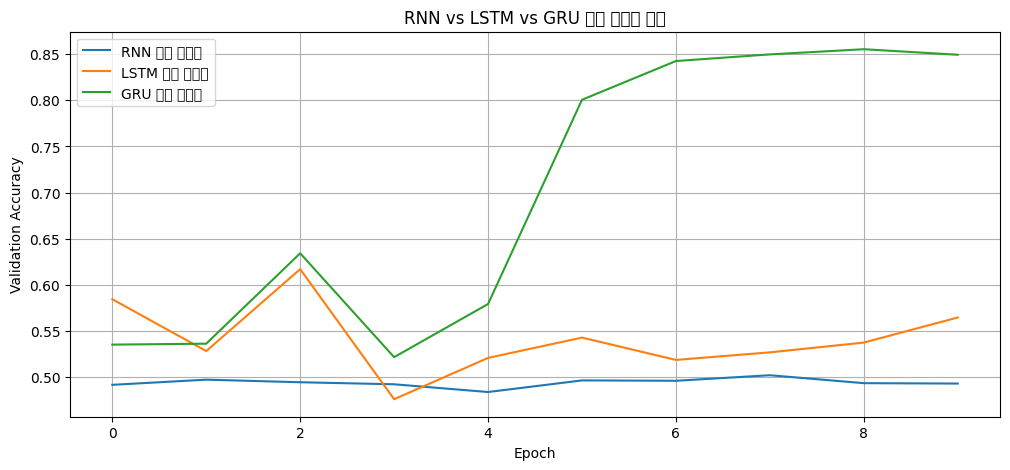

In [ ]:
plt.figure(figsize=(12, 5))
for cell in results:
    plt.plot(results[cell]['history']['val_accuracy'],
             label=f'{cell} 검증 정확도')
plt.title('RNN vs LSTM vs GRU 검증 정확도 비교')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## 6단계. 생각해봐주세요 !

실습 결과를 바탕으로 아래 질문에 답해보세요.

1. **정확도**: RNN, LSTM과 GRU 중 어느 모델의 테스트 정확도가 더 높나요? 그 차이가 통계적으로 유의미해 보이는 수준인가요, 아니면 오차 범위 수준인가요? 결과가 왜 이렇게 나왔는지 이유까지 설명해주세요.
2. **속도**: 학습 시간과 추론 시간에서 GRU가 LSTM보다 빨랐나요? 그 차이가 통계적으로 유의미해 보이는 수준인가요, 아니면 오차 범위 수준인가요? 결과가 왜 이렇게 나왔는지 이유까지 설명해주세요.
3. **하이퍼파라미터 실험**: `RNN_units`나 `epochs`, `max_len`, 'batch_size' 등을  바꿔가며 다시 실행해보고, 결과가 어떻게 달라지는지 관찰해보세요.

### 1. 정확도

시드 3개로 반복 측정한 테스트 정확도는 GRU 0.8128, LSTM 0.8043, SimpleRNN 0.5200이다.

GRU와 LSTM의 차이는 0.85%p이고 Welch 검정 p=0.703으로, 시드를 바꿀 때 생기는
변동 폭 안에 들어간다. 오차 범위 수준이라 어느 쪽이 낫다고 말할 수 없다. 반면
SimpleRNN과의 29%p 차이는 테스트셋 표본오차 ±0.6%p보다 훨씬 커서 분명한 차이다.

SimpleRNN이 낮은 이유는 max_len이 200이라 200스텝을 거치며 앞부분 정보가
사라지기 때문이다. 학습 정확도는 0.8103까지 오르는데 검증 정확도가 0.4930에
머무는 것이 근거다. 패턴을 일반화하지 못하고 학습 데이터만 외운 상태다.
LSTM과 GRU는 게이트로 이전 상태를 그대로 통과시키는 경로가 있어 이 문제를 피한다.

### 2. 속도

시드 3개 평균으로 학습은 GRU 3.94초, LSTM 3.98초, SimpleRNN 5.55초다.
추론은 GRU 0.70초, LSTM 0.61초로 LSTM이 더 빨랐다.

GRU와 LSTM의 학습 시간 차이는 0.04초로 시드 간 표준편차 0.10초보다 작고
Welch p=0.659다. 추론 시간도 p=0.511이다. 둘 다 오차 범위 수준이라
GRU가 빠르다고 말할 근거가 없다.

이론상 GRU는 게이트가 3개, LSTM은 4개라 순환층 연산이 25% 적어야 한다.
그런데 LSTM 전체 파라미터 328,353개 중 순환층은 8,320개로 2.5%뿐이고
나머지 320,000개가 임베딩이다. 순환층에서 아낀 연산이 전체 시간에 거의
반영되지 않는다.

SimpleRNN은 순환층 파라미터가 2,080개로 가장 적은데도 40% 느렸다.
Keras의 LSTM과 GRU는 조건이 맞으면 cuDNN 융합 커널로 시간 축을 한 번에
처리하지만 SimpleRNN에는 그 커널이 없어 200스텝을 하나씩 돌기 때문이다.
이 구간의 속도는 파라미터 수가 아니라 커널 최적화 여부가 결정한다.

In [ ]:
from scipy import stats

SEEDS = [42, 7, 2024]
CELLS = ['RNN', 'LSTM', 'GRU']


class BestWeightTracker(tf.keras.callbacks.Callback):
    """검증 정확도가 가장 높았던 시점의 가중치를 보관한다."""

    def on_train_begin(self, logs=None):
        self.best_acc, self.best_epoch, self.best_weights = -1.0, -1, None

    def on_epoch_end(self, epoch, logs=None):
        if logs['val_accuracy'] > self.best_acc:
            self.best_acc = logs['val_accuracy']
            self.best_epoch = epoch + 1
            self.best_weights = self.model.get_weights()


records = []
for seed in SEEDS:
    for cell in CELLS:
        tf.keras.utils.set_random_seed(seed)
        model = build_model(cell)
        timer, tracker = EpochTimer(), BestWeightTracker()

        model.fit(x_train, y_train,
                  epochs=epochs, batch_size=batch_size,
                  validation_split=0.2, verbose=0,
                  callbacks=[timer, tracker])

        final_acc = model.evaluate(x_test, y_test, verbose=0)[1]

        model.predict(x_test[:512], batch_size=256, verbose=0)   # 워밍업
        infer = []
        for _ in range(3):
            t0 = time.time()
            model.predict(x_test, batch_size=256, verbose=0)
            infer.append(time.time() - t0)

        model.set_weights(tracker.best_weights)
        best_acc = model.evaluate(x_test, y_test, verbose=0)[1]

        # 1에폭은 그래프 컴파일 시간이 섞여 있어 평균에서 제외
        sec = float(np.mean(timer.epoch_times[1:]))
        records.append({'model': cell, 'seed': seed,
                        'test_acc_final': final_acc, 'test_acc_best': best_acc,
                        'best_epoch': tracker.best_epoch,
                        'sec_per_epoch': sec, 'infer_sec': float(np.mean(infer)),
                        'params': model.count_params()})
        print(f"seed {seed:>4} | {cell:4s} | test {final_acc:.4f} | "
              f"best {best_acc:.4f} @ep{tracker.best_epoch:<2} | "
              f"{sec:.2f}s/epoch | infer {np.mean(infer):.2f}s")

df = pd.DataFrame(records)

print('\n=== 시드 3개 요약 (mean / std) ===')
print(df.groupby('model')[['test_acc_best', 'test_acc_final',
                           'sec_per_epoch', 'infer_sec']].agg(['mean', 'std']).round(4).to_string())

print('\n=== 파라미터 구성 ===')
emb_dense = vocab_size * embedding_dim + (RNN_units + 1)
for m in CELLS:
    tot = int(df.loc[df.model == m, 'params'].iloc[0])
    print(f"{m:4s} 전체 {tot:,} / 순환층 {tot - emb_dense:,}")

print('\n=== 테스트셋 25,000개 기준 이항 표본오차 ===')
for m in CELLS:
    p = df.loc[df.model == m, 'test_acc_best'].mean()
    print(f"{m:4s} 정확도 {p:.4f} ± {1.96 * np.sqrt(p * (1 - p) / len(y_test)):.4f}")

print('\n=== GRU vs LSTM, 시드 간 변동 대비 검정 ===')
for metric, unit in [('test_acc_best', ''), ('sec_per_epoch', '초'), ('infer_sec', '초')]:
    a = df.loc[df.model == 'GRU', metric].values
    b = df.loc[df.model == 'LSTM', metric].values
    _, p_val = stats.ttest_ind(a, b, equal_var=False)
    print(f"{metric:15s} 차이 {a.mean() - b.mean():+.4f}{unit}  Welch p={p_val:.3f}")
print('시드 3개라 검정력이 낮다. p가 크다고 차이가 없다는 뜻은 아니다.')


seed   42 | RNN  | test 0.5047 | best 0.5379 @ep3  | 5.36s/epoch | infer 1.30s
seed   42 | LSTM | test 0.7536 | best 0.8112 @ep7  | 3.90s/epoch | infer 0.57s
seed   42 | GRU  | test 0.7807 | best 0.7807 @ep10 | 3.90s/epoch | infer 0.58s
seed    7 | RNN  | test 0.5002 | best 0.5114 @ep4  | 5.92s/epoch | infer 0.60s
seed    7 | LSTM | test 0.7792 | best 0.7792 @ep10 | 4.10s/epoch | infer 0.62s
seed    7 | GRU  | test 0.8314 | best 0.8314 @ep10 | 4.05s/epoch | infer 0.93s
seed 2024 | RNN  | test 0.5106 | best 0.5106 @ep10 | 5.37s/epoch | infer 0.61s
seed 2024 | LSTM | test 0.8224 | best 0.8224 @ep10 | 3.93s/epoch | infer 0.63s
seed 2024 | GRU  | test 0.8262 | best 0.8262 @ep10 | 3.87s/epoch | infer 0.59s

=== 시드 3개 요약 (mean / std) ===
      test_acc_best         test_acc_final         sec_per_epoch         infer_sec        
               mean     std           mean     std          mean     std      mean     std
model                                                                       

### 3. 하이퍼파라미터 실험

기준 설정에서 한 번에 하나씩 바꿔 8에폭씩 돌린 결과, 변수마다 효과의 크기와
방향이 달랐다.

max_len이 가장 크게 작용했다. 400으로 늘리자 테스트 정확도가 LSTM은 0.8228에서
0.5274로, GRU는 0.8023에서 0.5037로 무너졌고 에폭 시간은 2.4초 늘었다. 시퀀스가
길어지면 순환층이 거쳐야 할 스텝이 두 배가 되어 학습이 안정적으로 진행되지 않는다.
100으로 줄이면 시간은 0.7~0.9초 줄지만 정확도도 0.065에서 0.089만큼 떨어진다.
뒷부분이 잘려 정보가 사라지기 때문이다.

units와 batch_size는 두 모델에서 방향이 반대였다. units=64에서 GRU는 +0.026,
LSTM은 -0.049였다. batch_size=128에서 GRU는 +0.044로 전체 조합 중 가장 높은
0.8460을 기록한 반면 LSTM은 -0.246으로 크게 떨어졌다. 8에폭 안에서 LSTM은 아직
수렴 중이라 업데이트 횟수가 줄면 손해를 보고, GRU는 이미 수렴해서 큰 배치의
안정적인 그래디언트가 오히려 도움이 된 것으로 보인다.

epochs는 기준 설정에서 두 모델 모두 best_epoch가 8, 마지막 에폭이었다. 8에폭으로는
아직 성능이 오르는 중이라는 뜻이고, 고정 에폭으로 비교하면 어디서 끊느냐에 따라
순위가 바뀔 수 있다.

In [ ]:
SWEEP_SEED = 42
SWEEP_EPOCHS = 8
BASE = {'units': 32, 'max_len': 200, 'batch_size': 64}
VARIANTS = [('units', 16), ('units', 64),
            ('max_len', 100), ('max_len', 400),
            ('batch_size', 32), ('batch_size', 128)]

(raw_train, y_tr), (raw_test, y_te) = imdb.load_data(num_words=vocab_size)
_cache = {}


def get_data(length):
    if length not in _cache:
        _cache[length] = (
            pad_sequences(raw_train, maxlen=length, padding='post', truncating='post'),
            pad_sequences(raw_test, maxlen=length, padding='post', truncating='post'))
    return _cache[length]


def build_cfg(cell_type, units):
    layer = {'RNN': SimpleRNN, 'LSTM': LSTM, 'GRU': GRU}[cell_type]
    model = Sequential([Embedding(input_dim=vocab_size, output_dim=embedding_dim),
                        layer(units),
                        Dense(1, activation='sigmoid')])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


def run_cfg(cfg, cell_type, tag):
    x_tr, x_te = get_data(cfg['max_len'])
    tf.keras.utils.set_random_seed(SWEEP_SEED)
    model = build_cfg(cell_type, cfg['units'])
    timer = EpochTimer()
    hist = model.fit(x_tr, y_tr, epochs=SWEEP_EPOCHS, batch_size=cfg['batch_size'],
                     validation_split=0.2, verbose=0, callbacks=[timer]).history
    val = hist['val_accuracy']
    return {'변경': tag, 'model': cell_type,
            'best_val': max(val), 'best_epoch': int(np.argmax(val)) + 1,
            'final_val': val[-1],
            'test_acc': model.evaluate(x_te, y_te, verbose=0)[1],
            'sec_per_epoch': float(np.mean(timer.epoch_times[1:]))}


sweep = []
for cell in ['LSTM', 'GRU']:
    sweep.append(run_cfg(BASE, cell, '기준'))
    for key, value in VARIANTS:
        cfg = dict(BASE)
        cfg[key] = value
        sweep.append(run_cfg(cfg, cell, f'{key}={value}'))
    print(f'{cell} 완료')

sweep_df = pd.DataFrame(sweep)
print('\n=== 전체 결과 ===')
print(sweep_df.round(4).to_string(index=False))

print('\n=== 기준 대비 변화량 ===')
cols = ['best_val', 'test_acc', 'sec_per_epoch']
for cell in ['LSTM', 'GRU']:
    sub = sweep_df[sweep_df.model == cell].set_index('변경')
    print(f'\n[{cell}]  기준 best_epoch = {sub.loc["기준", "best_epoch"]}')
    print((sub[cols] - sub.loc['기준', cols]).drop(index='기준').round(4).to_string())


LSTM 완료
GRU 완료

=== 전체 결과 ===
            변경 model  best_val  best_epoch  final_val  test_acc  sec_per_epoch
            기준  LSTM    0.8408           8     0.8408    0.8228         3.9561
      units=16  LSTM    0.6382           1     0.6090    0.6006         3.9862
      units=64  LSTM    0.8220           6     0.7782    0.7734         3.9277
   max_len=100  LSTM    0.8262           3     0.7528    0.7341         3.2645
   max_len=400  LSTM    0.5374           5     0.5362    0.5274         6.3443
 batch_size=32  LSTM    0.7906           4     0.6728    0.6575         7.6397
batch_size=128  LSTM    0.7632           6     0.5890    0.5768         2.0699
            기준   GRU    0.8182           8     0.8182    0.8023         3.8950
      units=16   GRU    0.8418           7     0.8406    0.8247         3.8162
      units=64   GRU    0.8478           5     0.8346    0.8280         3.8536
   max_len=100   GRU    0.8302           3     0.7784    0.7373         3.0249
   max_len=400   GRU  

**정답을 원하는 것이 아닙니다. 실습만 해보는 것이 아니라 결과에 대해 고민해보는 시간을 가지셨으면 좋겠습니다 ! 그럼 다들 BASE 활동 파이팅 하세요 😊**